# Klein VAE Experiments

In [3]:
%load_ext autoreload
%autoreload 2

import rootutils
root = rootutils.setup_root(search_from=".", indicator=".project-root", pythonpath=True, cwd=True)

In [4]:
from src.data.uniform_filters_datamodule import UniformFiltersDataModule
from src.models.klein_vae_module import KleinVAEModule
from src.models.components.vae import SimpleVAE

from src.data.components.utils import generate_klein_filter_matrix
from src.utils import project_to_klein

import matplotlib.pyplot as plt

from lightning.pytorch.trainer import Trainer
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import torch

import random
import numpy as np
import pandas as pd

from ripser import ripser
from persim import plot_diagrams


In [5]:
BATCH_SIZE = 16

Total training examples: 8000


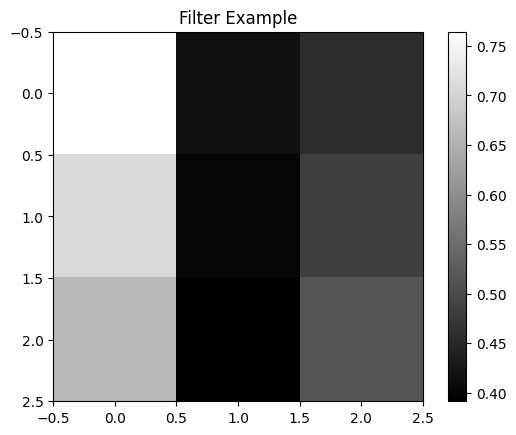

In [5]:
datamodule = UniformFiltersDataModule(num_samples_per_angle=100, batch_size=BATCH_SIZE)
datamodule.setup()
filter_example = datamodule.train_dataloader().dataset[0][0].reshape(3,3)

train_loader = datamodule.train_dataloader()
total_examples = len(train_loader.dataset)
print(f"Total training examples: {total_examples}")

plt.imshow(filter_example, cmap='gray')
plt.colorbar()
plt.title('Filter Example')
plt.show()

### Testing that samples from `UniformFiltersDataModule` lie on the Klein bottle

In [148]:
dataset = datamodule.train_dataloader().dataset
indices = random.sample(range(len(dataset)), 500)
batch = np.array([dataset[i][0].numpy() for i in indices])

In [149]:
diagrams2 = ripser(batch, maxdim=2, coeff=2)['dgms']
diagrams3 = ripser(batch, maxdim=2, coeff=3)['dgms']

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_82822/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_82822/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


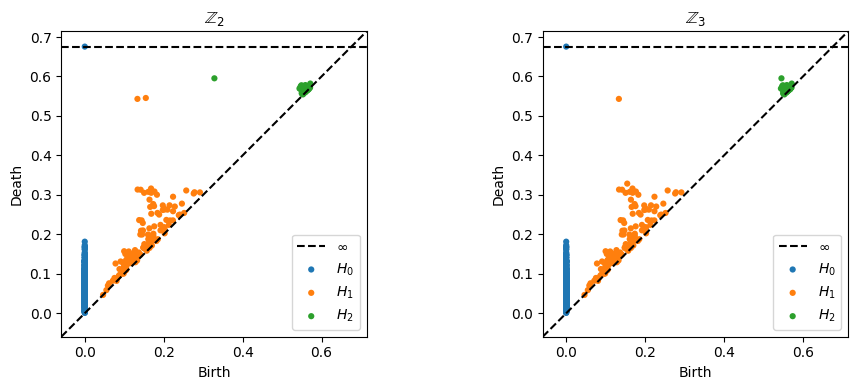

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

### Running the model

In [6]:
vae_model = SimpleVAE(hidden_dims=[32, 32, 32, 32, 32])
klein_vae_module = KleinVAEModule(model=vae_model, batch_size=BATCH_SIZE, lr=1e-3, kl_weight=0, sigma2=10)

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


#### Checking the filters BEFORE training

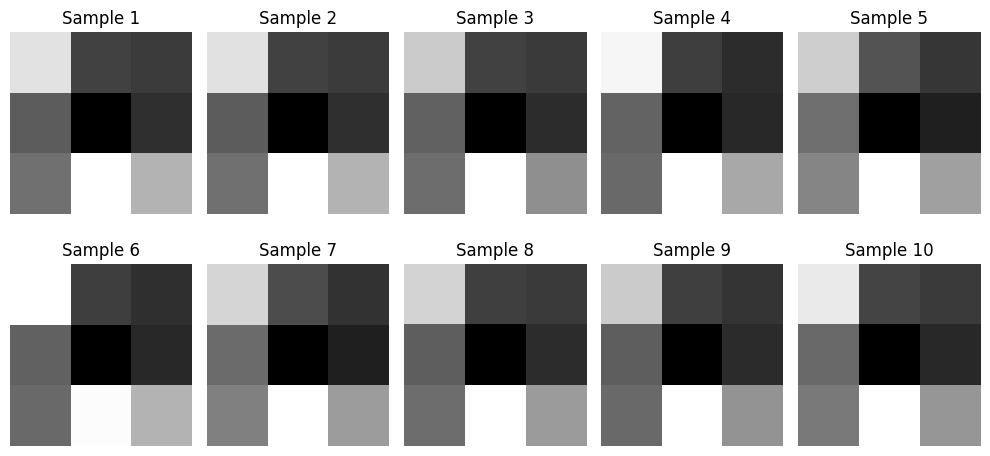

In [8]:
samples = klein_vae_module.sample(num_samples=10)
filters_from_decoder = klein_vae_module.model.decode(samples).reshape(-1, 3, 3)

plt.figure(figsize=(10, 5))
for i, filter_img in enumerate(filters_from_decoder):
    plt.subplot(2, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'Sample {i+1}')
plt.tight_layout()
plt.show()

In [9]:
samples = klein_vae_module.sample(num_samples=500)
decoded = klein_vae_module.model.decode(samples).detach().cpu().numpy()
batch = decoded

diagrams = ripser(batch, maxdim=2)['dgms']
plot_diagrams(diagrams, show=True, title='Persistence Diagrams for Decoded Filters')

NameError: name 'ripser' is not defined

### Training

In [9]:
klein_vae_module.use_decoder = True
klein_vae_module.kl_weight = 1e-3

In [10]:
trainer = Trainer(accelerator="cpu", max_epochs=100, enable_progress_bar=True)
trainer.fit(klein_vae_module, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | SimpleVAE | 9.3 K  | train
--------------------------------------------
9.3 K     Trainable params
0         Non-trainable params
9.3 K     Total params
0.037     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode


/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 500/500 [00:07<00:00, 69.37it/s, v_num=118, train_loss=0.655, recon_loss=0.628, kl_div=26.60, lr=0.000466] 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 500/500 [00:07<00:00, 69.28it/s, v_num=118, train_loss=0.655, recon_loss=0.628, kl_div=26.60, lr=0.000466]


In [11]:
# Retrieve and display the logged metrics after training
metrics = trainer.callback_metrics
print(metrics)

{'train_loss': tensor(0.6550), 'recon_loss': tensor(0.6283), 'kl_div': tensor(26.6384), 'lr': tensor(0.0005), 'val_loss': tensor(0.6643), 'val_recon_loss': tensor(0.6376), 'val_kl_div': tensor(26.6378)}


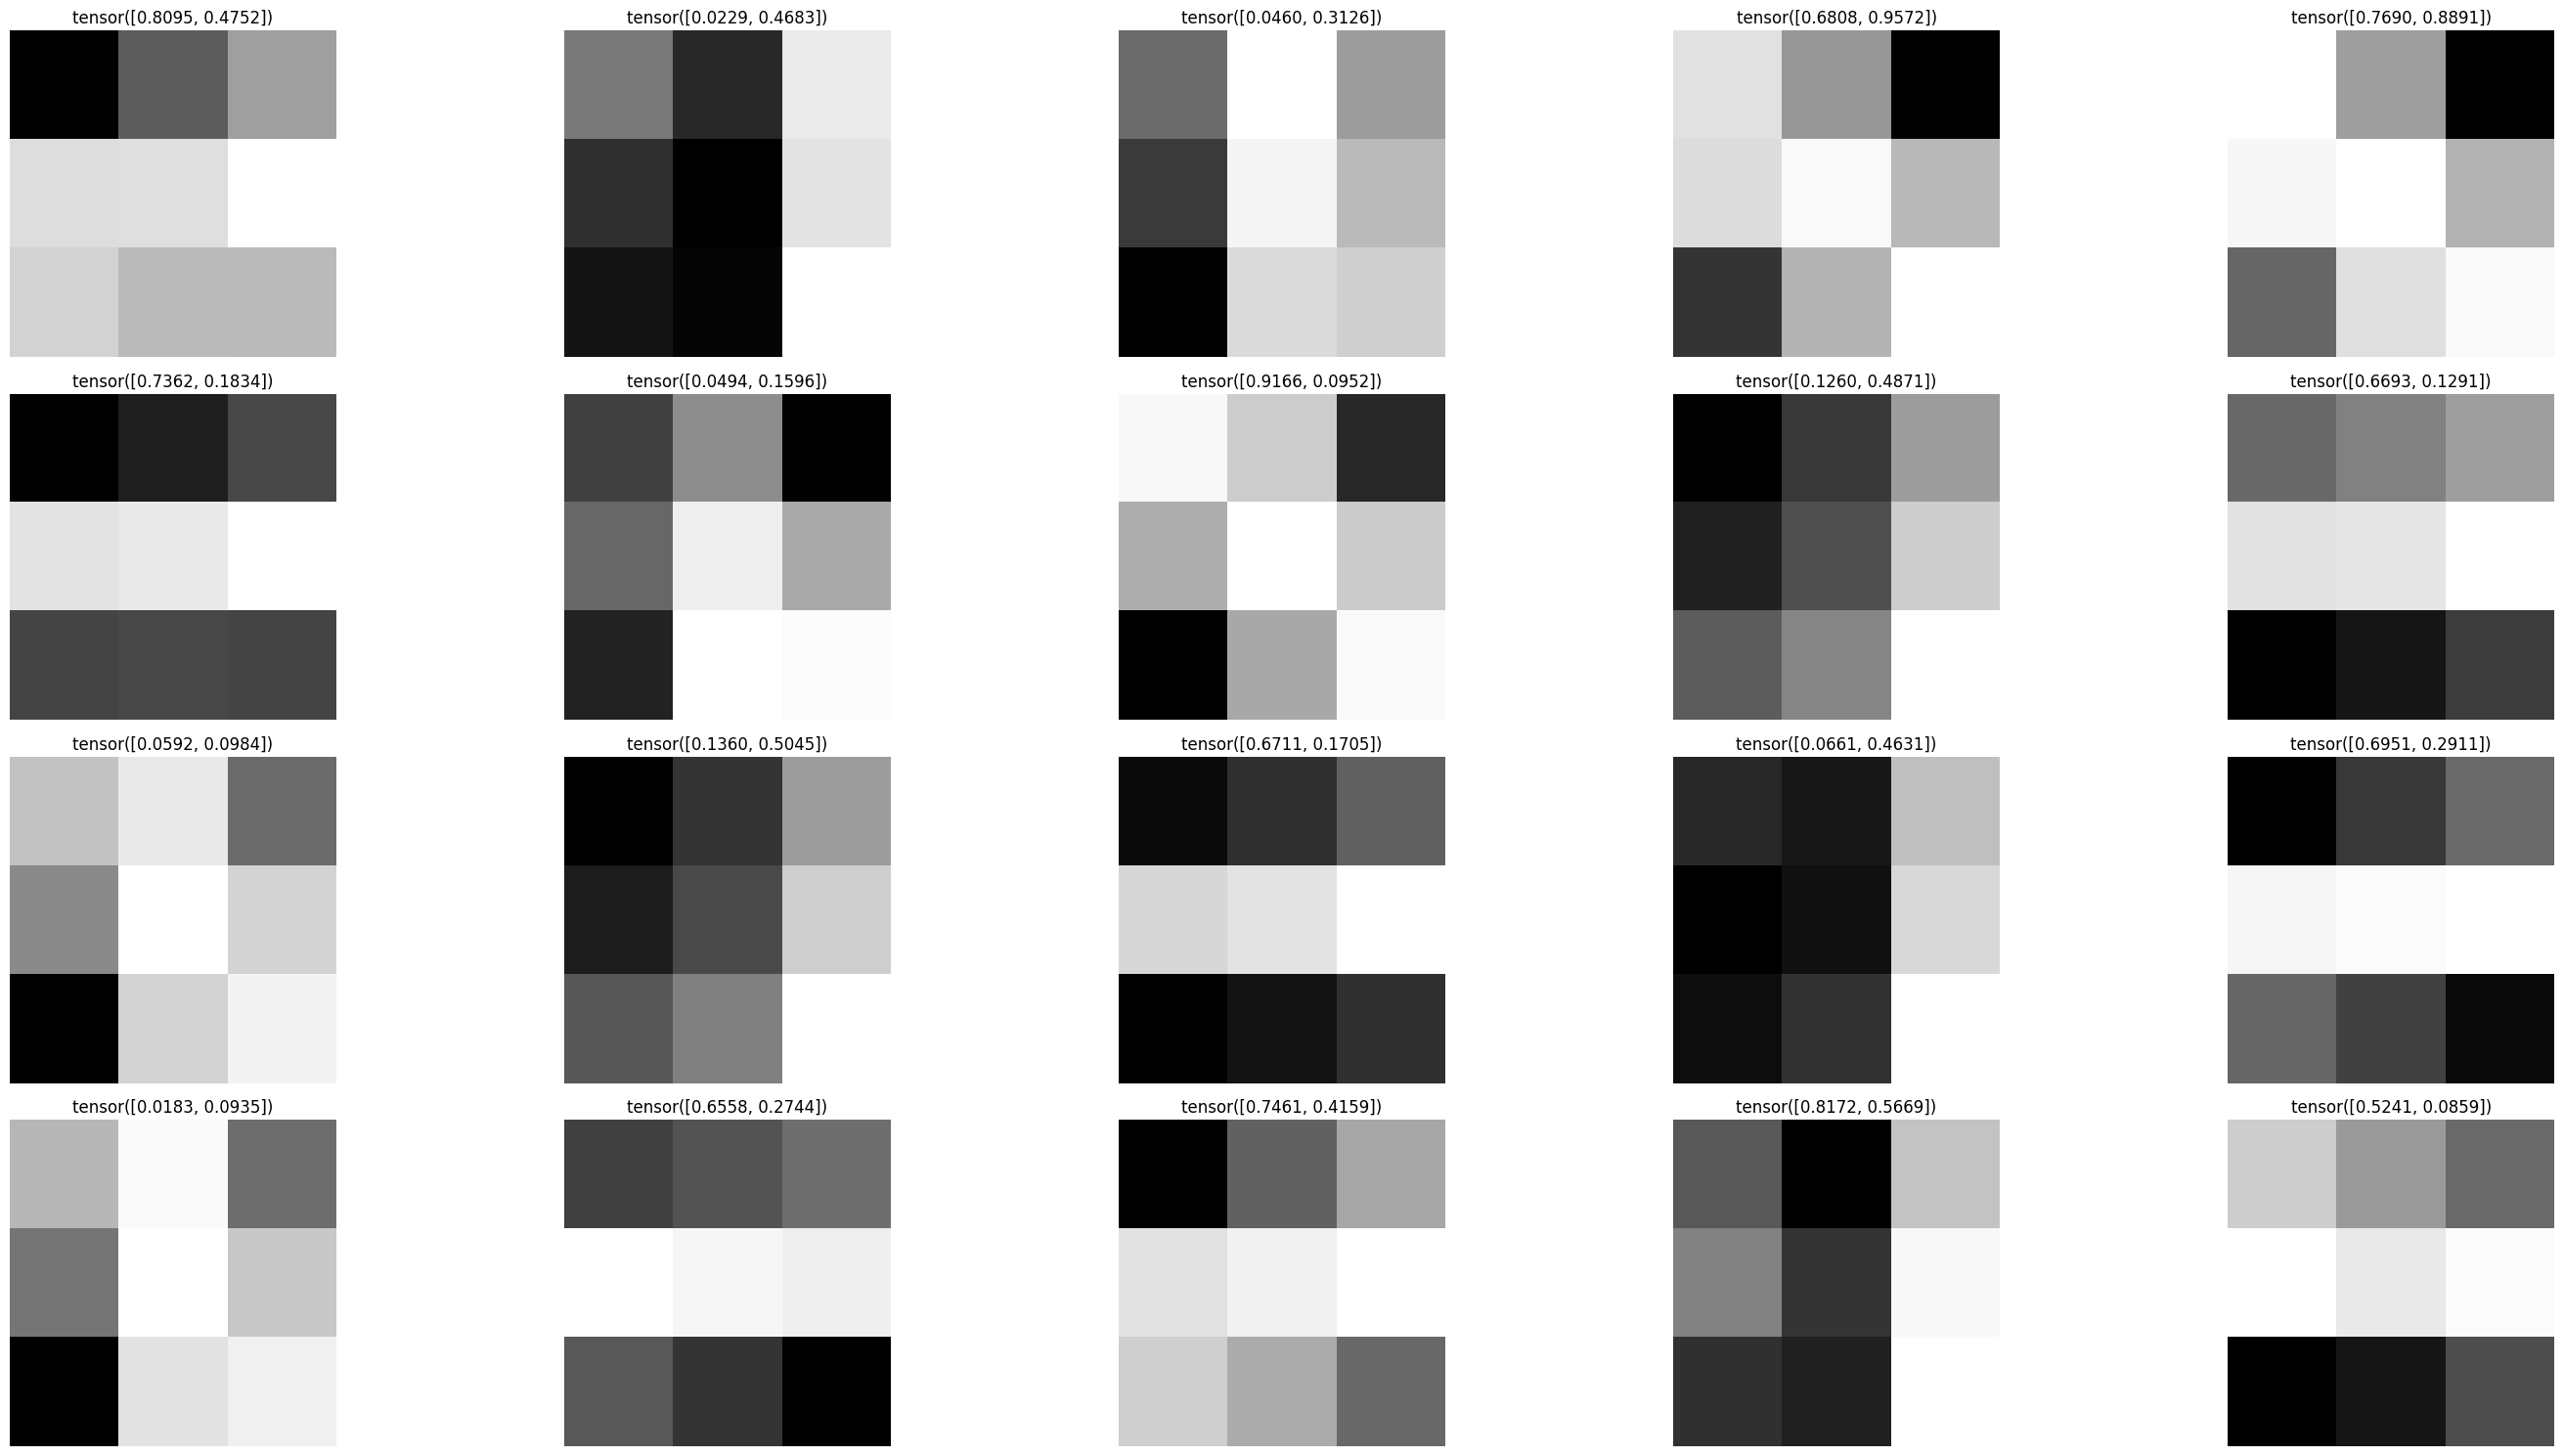

In [12]:
samples = klein_vae_module.sample(num_samples=20)
filters_from_decoder = klein_vae_module.decode(samples).reshape(-1,3,3)


plt.figure(figsize=(30, 15))
for i, filter_img in enumerate(filters_from_decoder):
    plt.subplot(4, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'{samples[i]}')
plt.tight_layout()
plt.show()

### Testing that decoded samples also lie on the Klein bottle

In [122]:
samples = klein_vae_module.sample(num_samples=500)
decoded = klein_vae_module.decode(samples)
batch = decoded.detach().cpu().numpy()

In [123]:
diagrams2 = ripser(batch, maxdim=2, coeff=2)['dgms']
diagrams3 = ripser(batch, maxdim=2, coeff=3)['dgms']

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_94022/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_94022/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


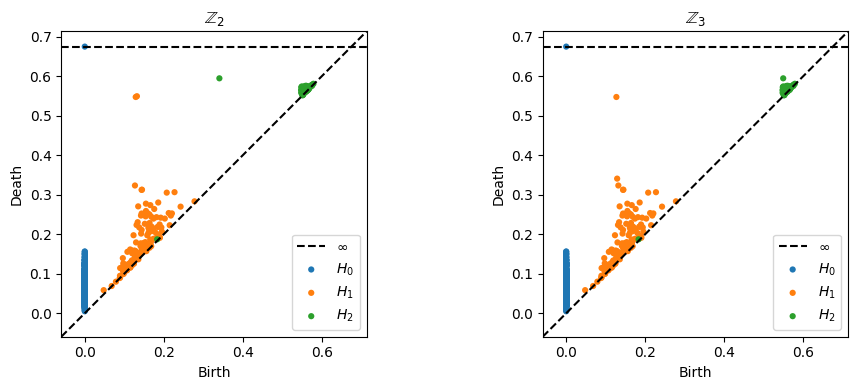

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

### Try to find the problem

In [25]:
n_points = 20

grid_on_flat_klein = torch.cartesian_prod(torch.linspace(0, 1, n_points), 
                                          torch.linspace(0, 1, n_points))
filters = torch.stack([generate_klein_filter_matrix(theta_1 * 2 * torch.pi, theta_2 * 2 * torch.pi, size=3, midpoint=False).flatten() 
                        for theta_1, theta_2 in grid_on_flat_klein])

In [14]:
mu_on_klein = project_to_klein(klein_vae_module.model.encode(filters)[0])
sigma_on_klein = klein_vae_module.model.encode(filters)[1]

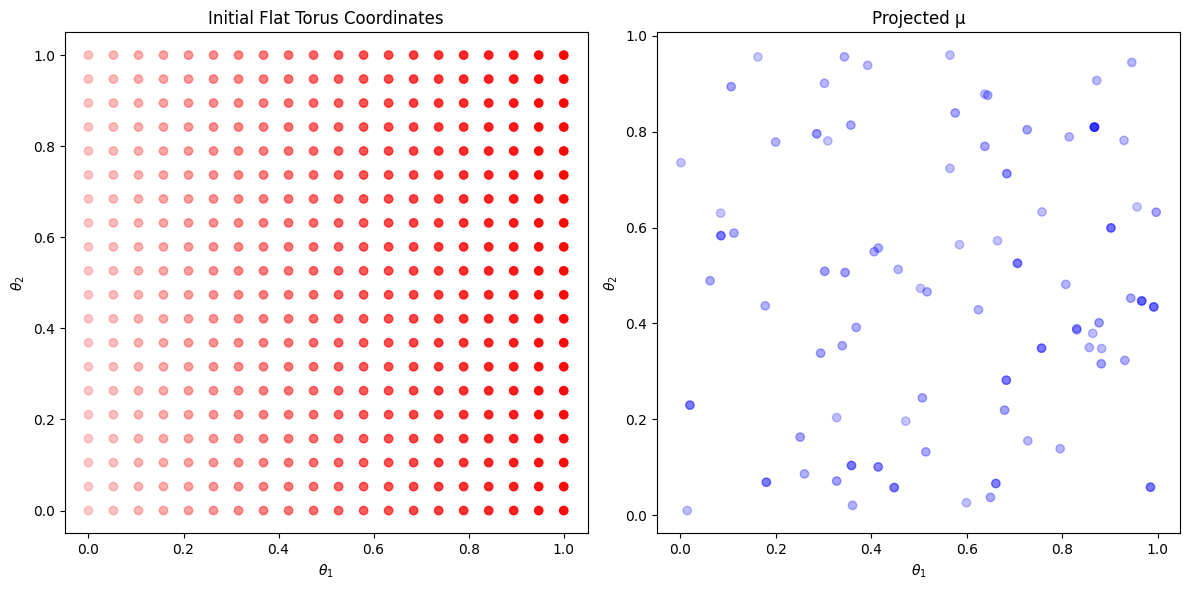

In [30]:
# scatter plot of initial grid coordinates vs. projected μ on the Klein bottle
initial_coords = grid_on_flat_klein.cpu().numpy()
klein_coords = mu_on_klein.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#axes[0].scatter(datamodule.coordinates[:, 0], datamodule.coordinates[:, 1], c='green', alpha=0.5, label='Uniform Samples')
#axes[0].legend()

axes[0].scatter(initial_coords[:, 0], initial_coords[:, 1], c='red', alpha=np.linspace(0.2,0.99,n_points**2))
axes[0].set_xlabel(r'$\theta_1$')
axes[0].set_ylabel(r'$\theta_2$')
axes[0].set_title('Initial Flat Torus Coordinates')

axes[1].scatter(klein_coords[:, 0], klein_coords[:, 1], c='blue', alpha=np.linspace(0.2,0.99,n_points**2))

axes[1].set_xlabel(r'$\theta_1$')
axes[1].set_ylabel(r'$\theta_2$')
axes[1].set_title('Projected μ')

plt.tight_layout()
plt.show()

127, 101, 256, 107

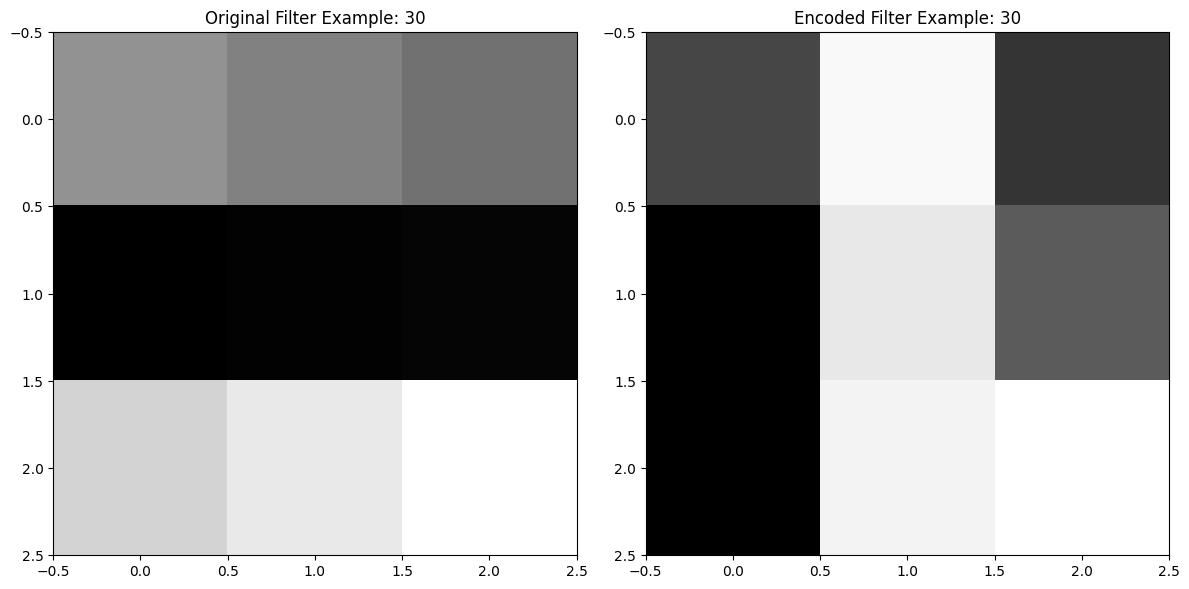

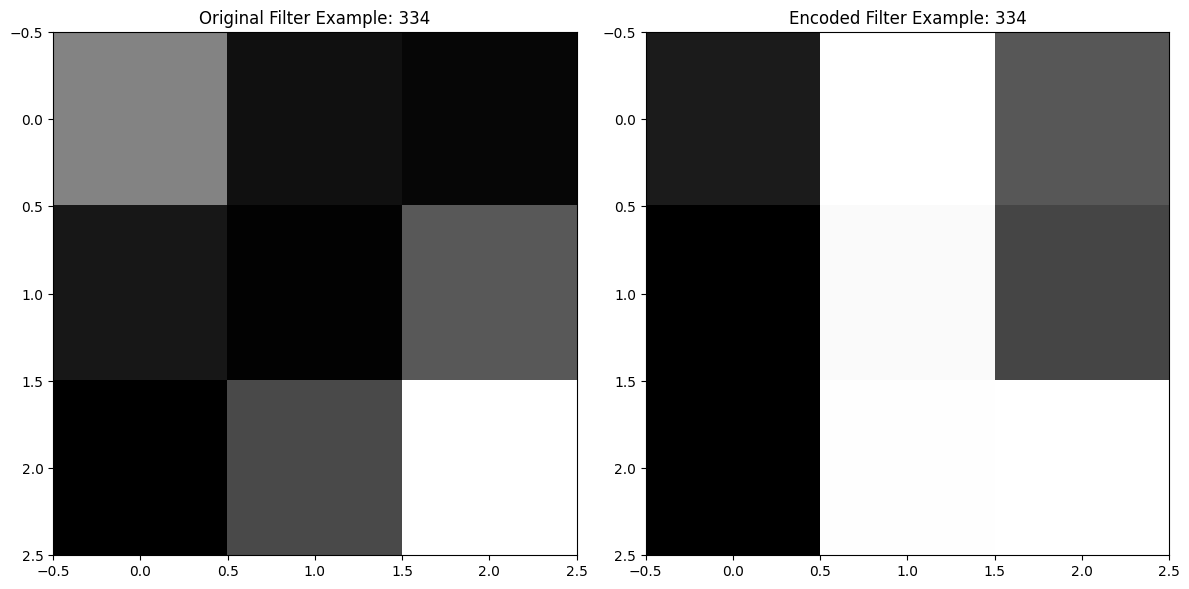

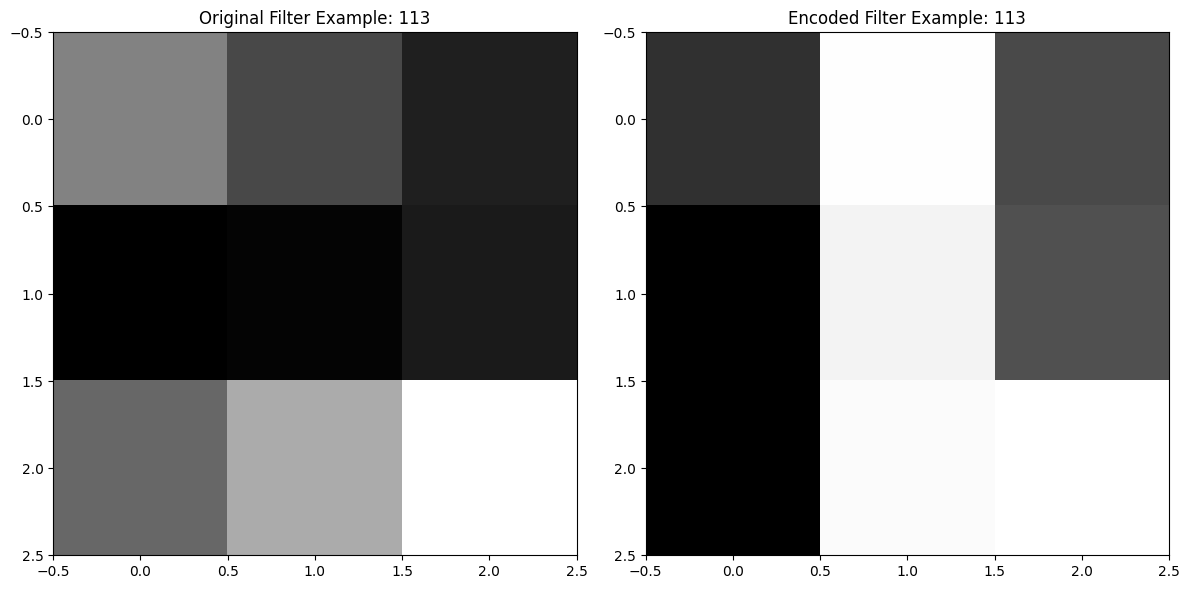

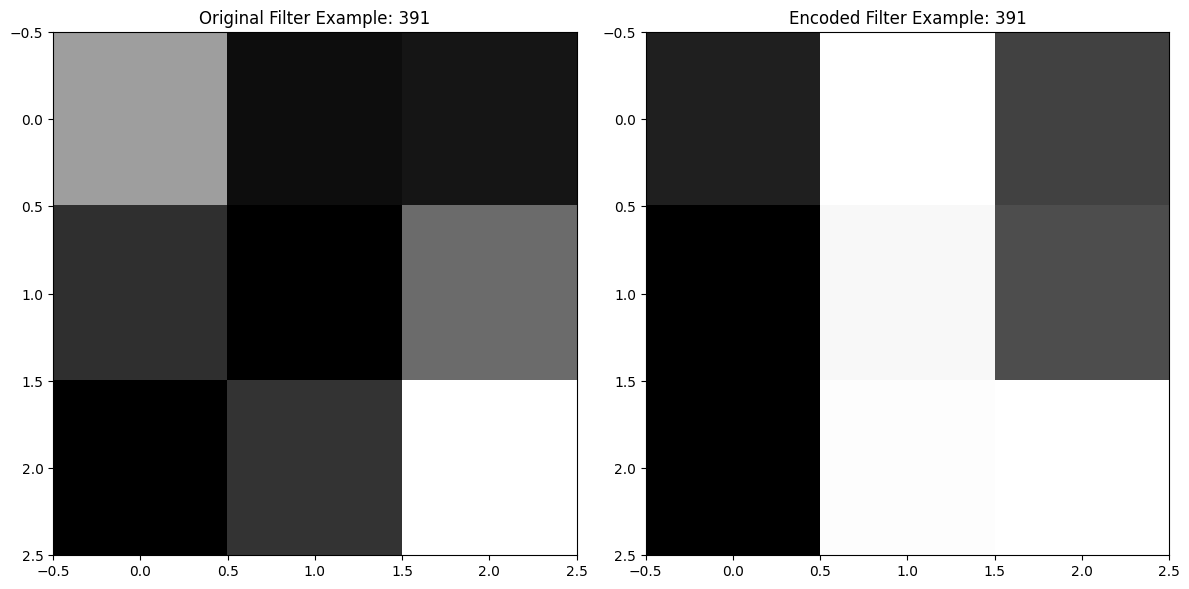

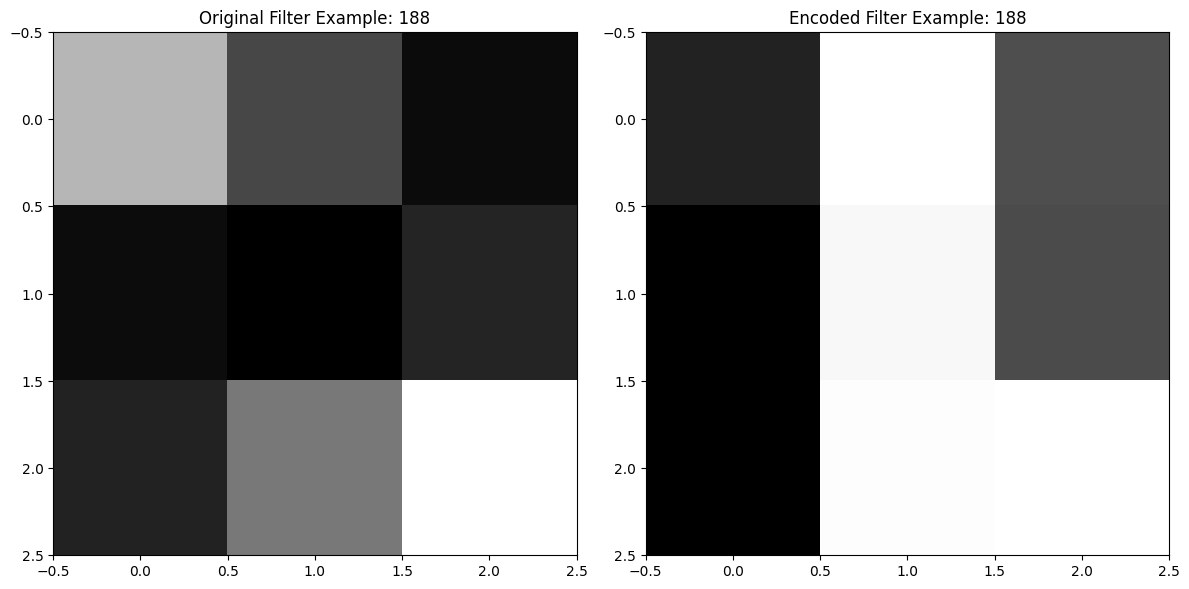

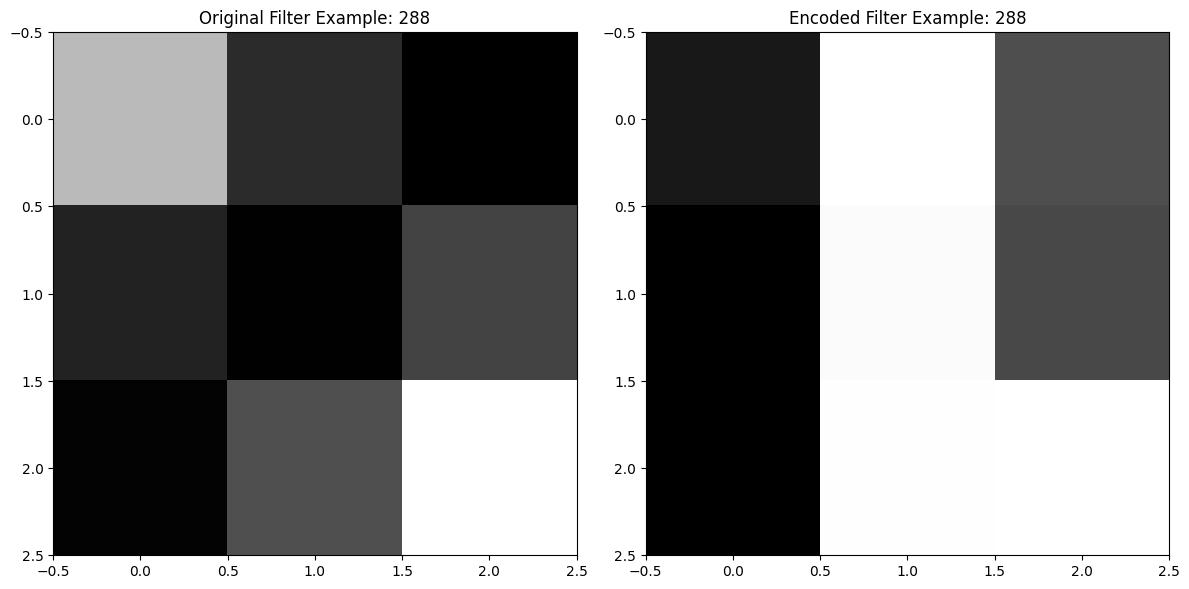

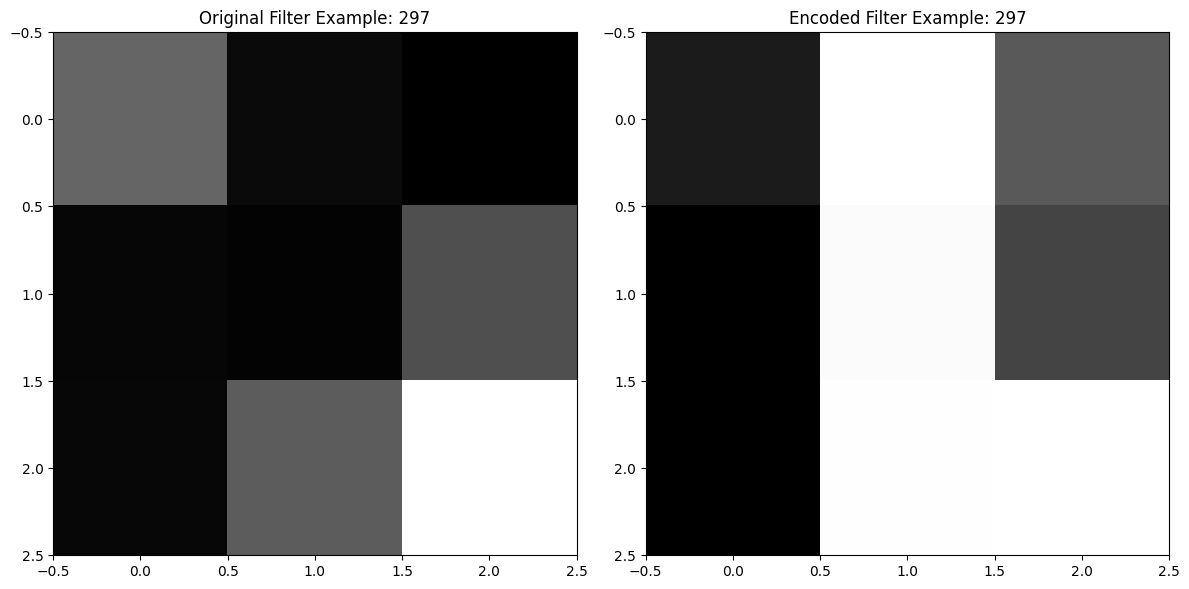

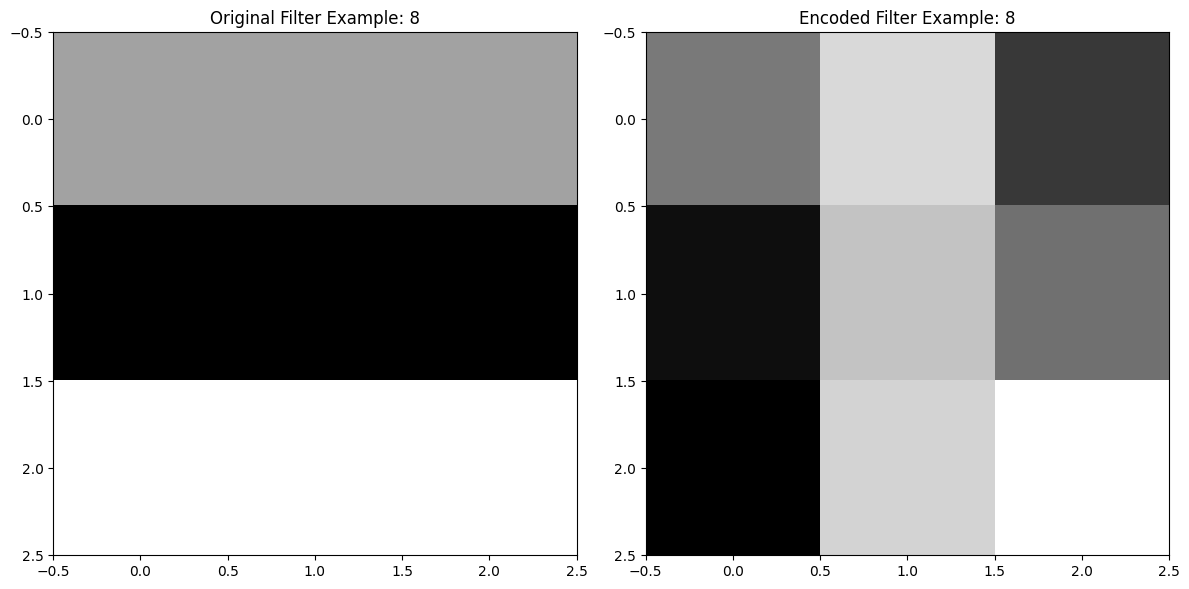

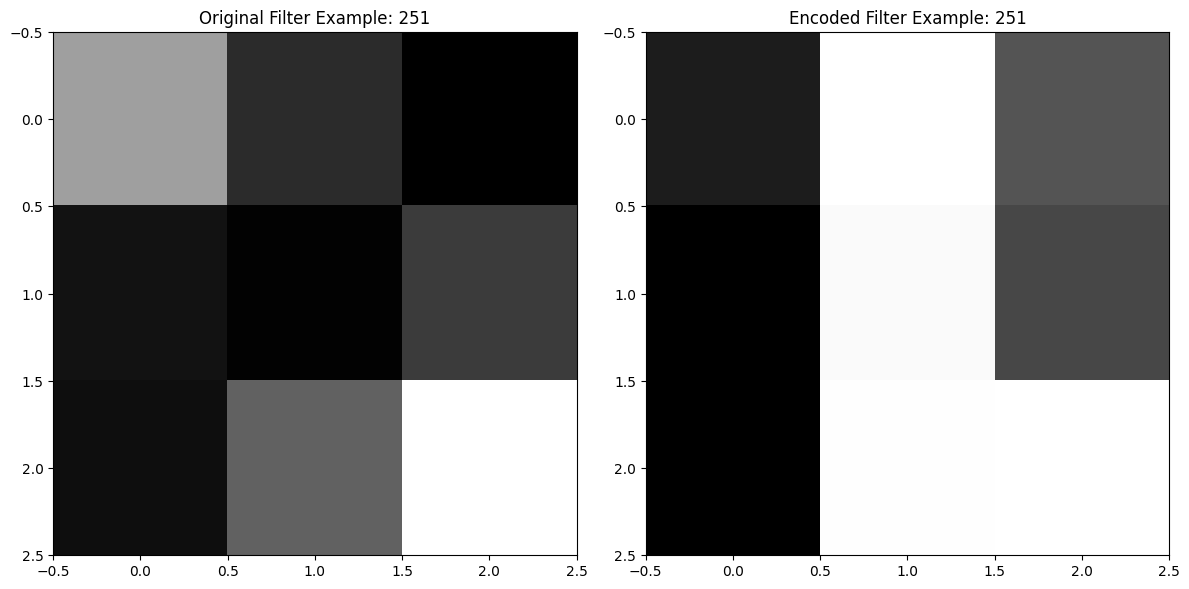

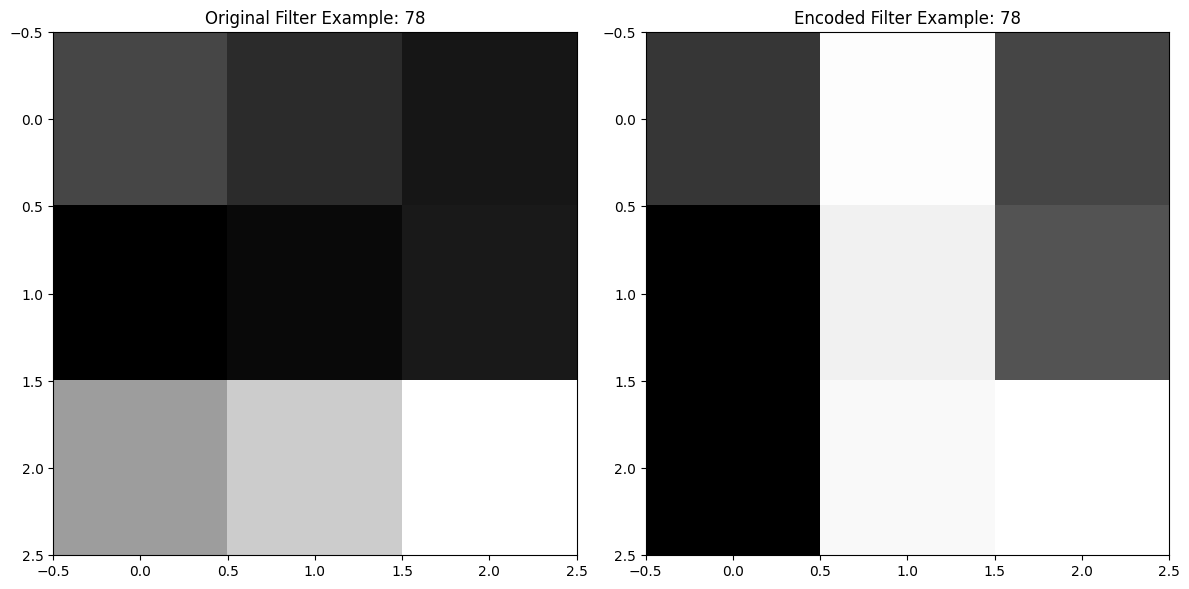

In [29]:
random_idx = np.random.randint(0, len(grid_on_flat_klein), size=10) 

for i in random_idx:
    filter_example = generate_klein_filter_matrix(grid_on_flat_klein[i][0], grid_on_flat_klein[i][1]) #datamodule.train_dataloader().dataset[i][0].reshape(3,3)
    encoded_coords = klein_vae_module.encode(filter_example.flatten())[0]
    reconstructed_filter = klein_vae_module.decode(encoded_coords.reshape(1,-1)).reshape(3,3)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(filter_example, cmap='gray')
    encoded_example = klein_vae_module.encode(filter_example.flatten())
    encoded_filter = klein_vae_module.decode(encoded_example[0].unsqueeze(0))
    axes[1].imshow(reconstructed_filter.reshape(3, 3).detach().cpu().numpy(), cmap='gray')
    axes[0].set_title(f'Original Filter Example: {i}')
    axes[1].set_title(f'Encoded Filter Example: {i}')
    plt.tight_layout()
    #plt.show()

In [20]:
filter_example, encoded_filter.reshape(3,3)

(tensor([[ 2.9439,  0.2352, -0.9439],
         [-0.2352, -1.0000, -0.2352],
         [-0.9439,  0.2352,  2.9439]]),
 tensor([[3.6793e-02, 9.9966e-01, 1.3667e-01],
         [1.5614e-06, 9.9428e-01, 2.5777e-01],
         [5.5654e-19, 9.9852e-01, 1.0000e+00]], grad_fn=<ViewBackward0>))

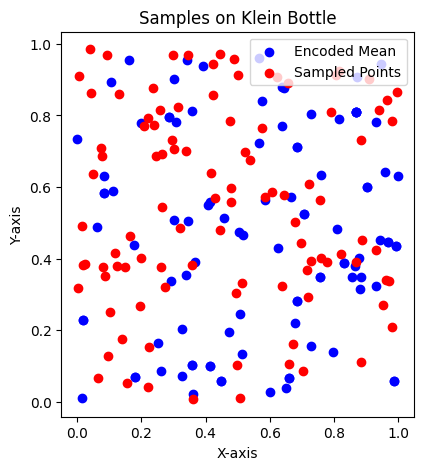

In [21]:
samples_on_klein, samples_from_model = klein_vae_module.sample(num_samples=100, return_unprojected=True)


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(mu_on_klein[:, 0].detach().cpu().numpy(), mu_on_klein[:, 1].detach().cpu().numpy(), c='blue', label='Encoded Mean')
plt.scatter(samples_on_klein[:, 0].detach().cpu().numpy(), samples_on_klein[:, 1].detach().cpu().numpy(), c='red', label='Sampled Points')
plt.title('Samples on Klein Bottle')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()

## VIsualising logs

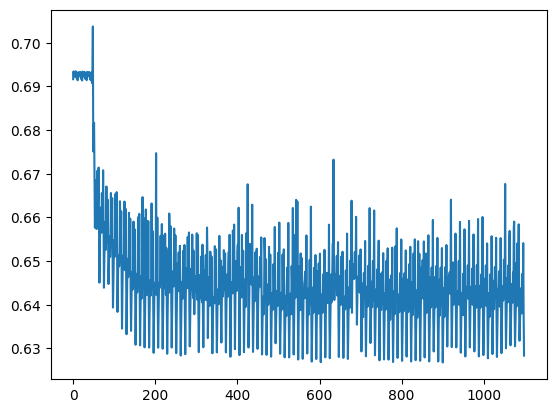

In [22]:
logs_dir = trainer.logger.log_dir

logs_df = pd.read_csv(f"{logs_dir}/metrics.csv")

plt.plot(logs_df['recon_loss'].dropna())

In [ ]:
#trainer.save_checkpoint("MODELS/16-32-64-checkpoint.ckpt")

## Circles Dataset

In [17]:
from src.data.circles_datamodule import CirclesDatamodule

In [25]:
IMG_SIZE = 30
BATCH_SIZE = 1024
datamodule = CirclesDatamodule(num_images=100000, image_linear_pixel_size=IMG_SIZE, batch_size=BATCH_SIZE)
datamodule.setup()

Epoch 0:   8%|▊         | 769/10000 [01:21<16:20,  9.41it/s, v_num=158, train_loss=0.585, recon_loss=0.581, kl_div=429.0, lr=0.001] 


Total training examples: 80000


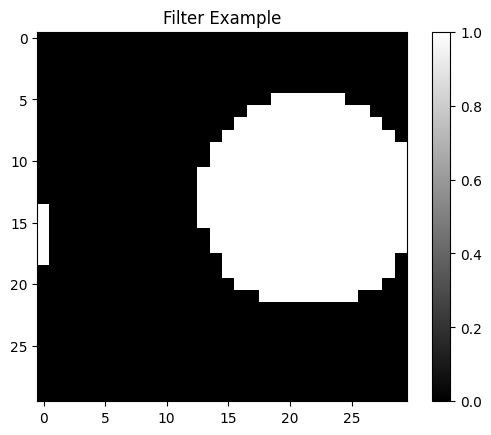

In [20]:
filter_example = datamodule.train_dataloader().dataset[100][0].reshape(IMG_SIZE,IMG_SIZE)

train_loader = datamodule.train_dataloader()
total_examples = len(train_loader.dataset)
print(f"Total training examples: {total_examples}")

plt.imshow(filter_example, cmap='gray')
plt.colorbar()
plt.title('Filter Example')
plt.show()

In [56]:
vae_model = SimpleVAE(input_dim=IMG_SIZE**2, hidden_dims=[1024, 512, 128, 32])
klein_vae_module = KleinVAEModule(model=vae_model, batch_size=BATCH_SIZE, lr=1e-3, kl_weight=1e-2, sigma2=0.1, use_decoder=True)

In [57]:
trainer = Trainer(accelerator="cpu", max_epochs=50, enable_progress_bar=True)#, callbacks=[EarlyStopping(monitor="recon_loss", patience=5, mode="min")])
trainer.fit(klein_vae_module, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | SimpleVAE | 3.0 M  | train
--------------------------------------------
3.0 M     Trainable params
0         Non-trainable params
3.0 M     Total params
12.142    Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████| 79/79 [00:02<00:00, 26.83it/s, v_num=164, train_loss=0.136, recon_loss=0.067, kl_div=6.910, lr=0.000755] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 79/79 [00:02<00:00, 26.59it/s, v_num=164, train_loss=0.136, recon_loss=0.067, kl_div=6.910, lr=0.000755]


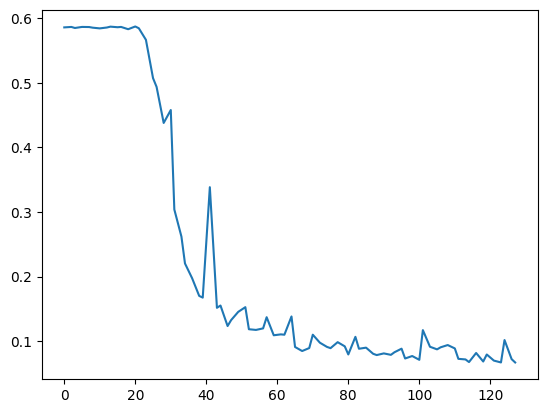

In [58]:
logs_dir = trainer.logger.log_dir

logs_df = pd.read_csv(f"{logs_dir}/metrics.csv")

plt.plot(logs_df['recon_loss'].dropna())

tensor([0.4374, 0.5971], grad_fn=<StackBackward0>)
tensor([0.6007, 0.3468], grad_fn=<StackBackward0>)
tensor([0.6771, 0.4460], grad_fn=<StackBackward0>)
tensor([0.7445, 0.6277], grad_fn=<StackBackward0>)
tensor([0.5311, 0.3841], grad_fn=<StackBackward0>)
tensor([0.1920, 0.5810], grad_fn=<StackBackward0>)
tensor([0.6056, 0.7367], grad_fn=<StackBackward0>)
tensor([0.7198, 0.5219], grad_fn=<StackBackward0>)
tensor([0.5123, 0.5542], grad_fn=<StackBackward0>)
tensor([0.5191, 0.3440], grad_fn=<StackBackward0>)


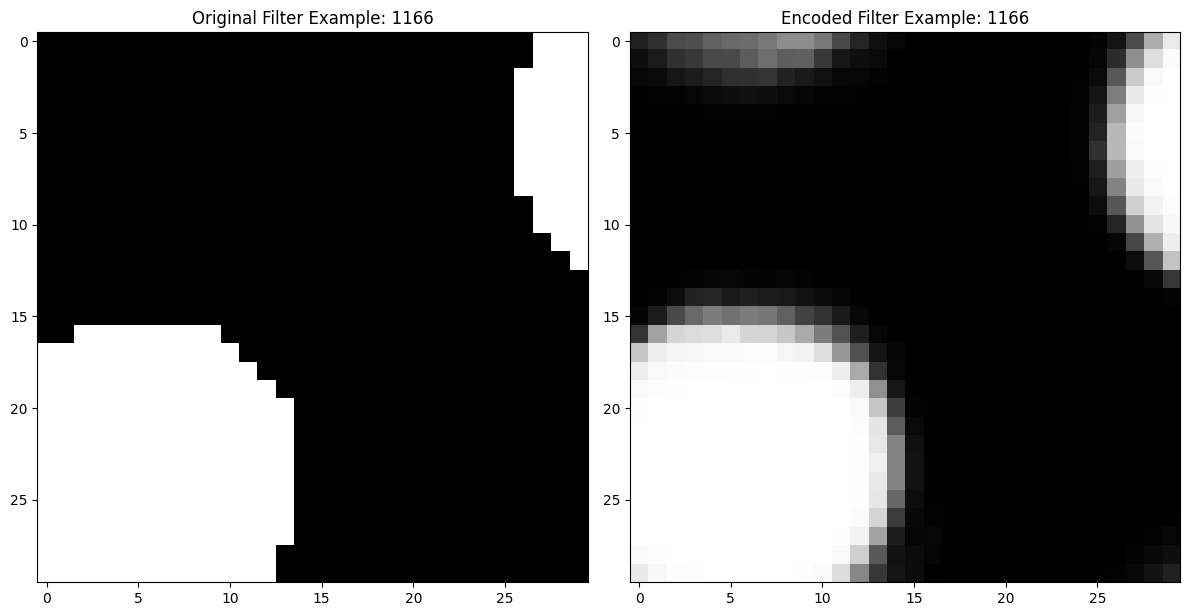

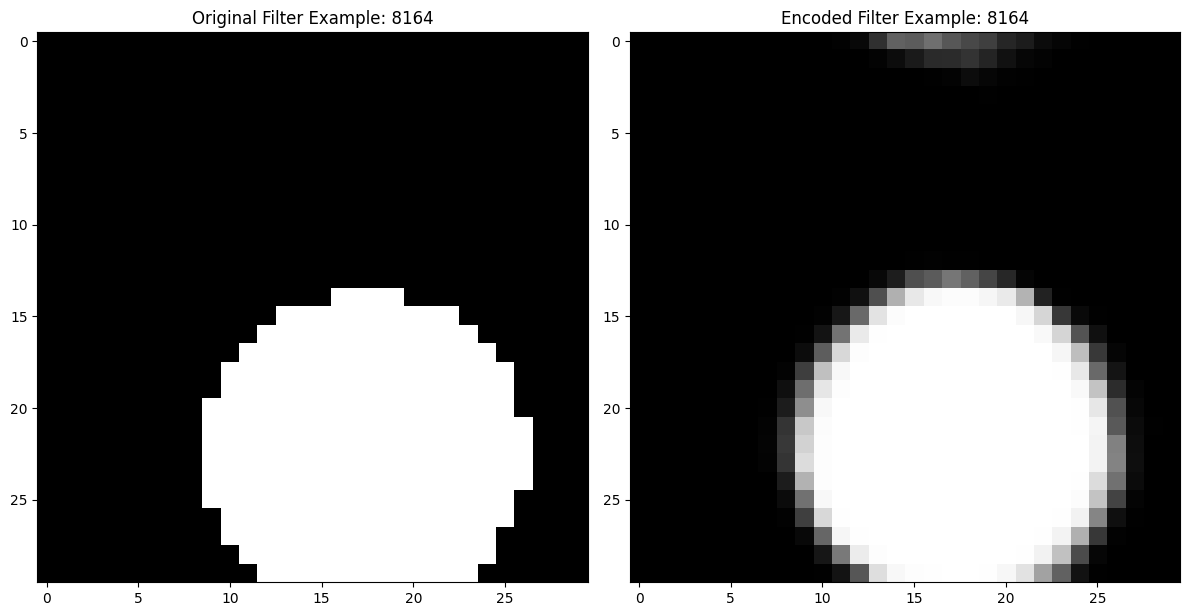

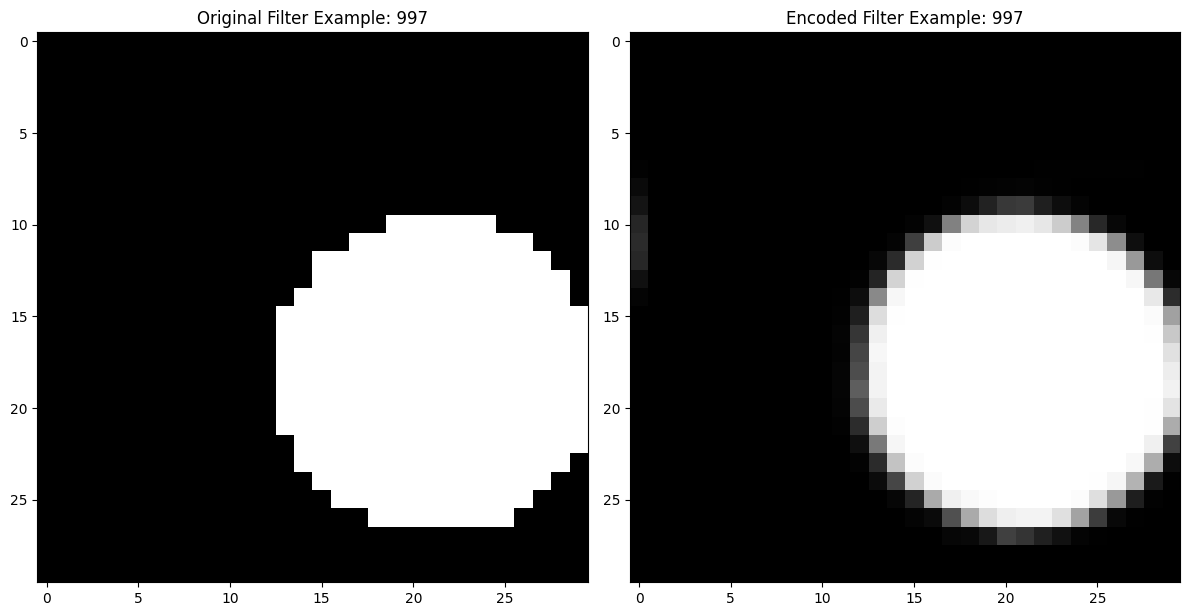

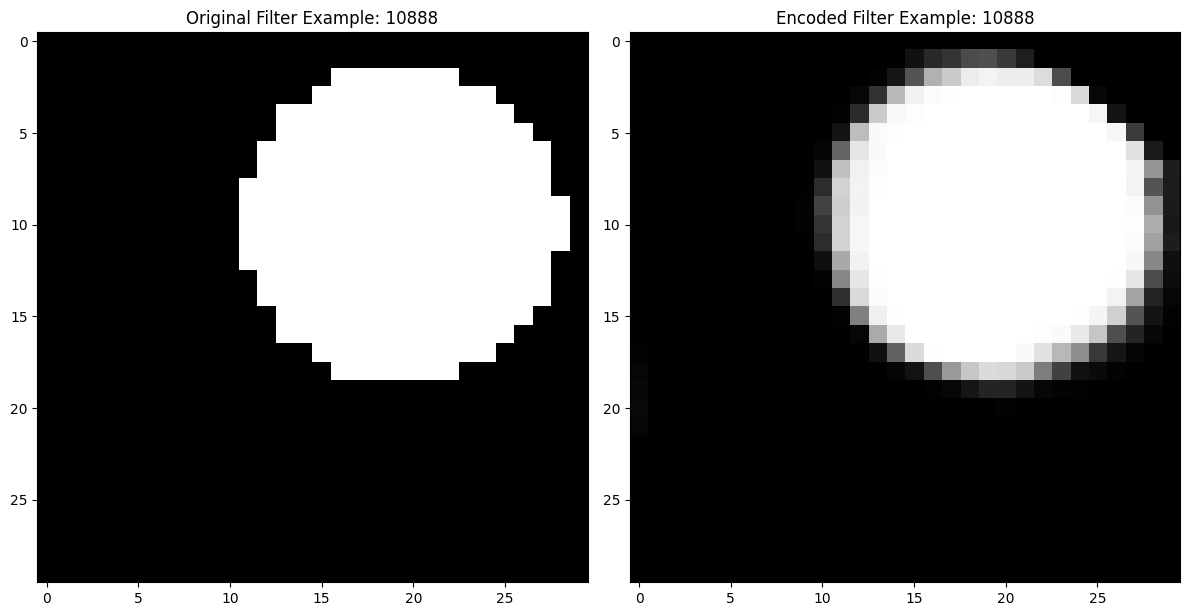

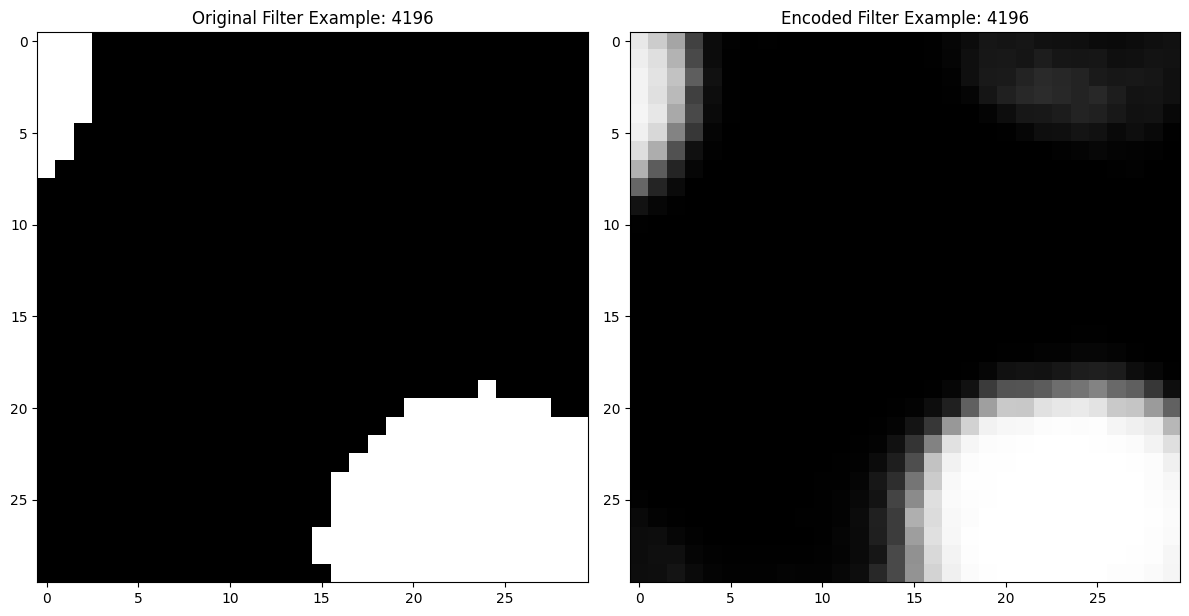

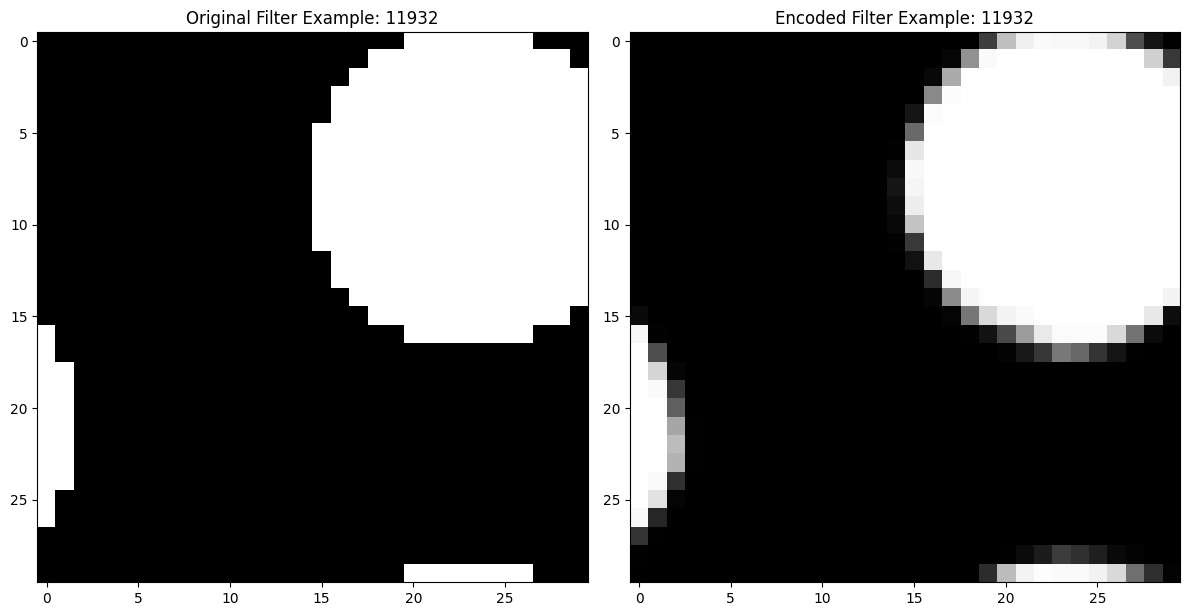

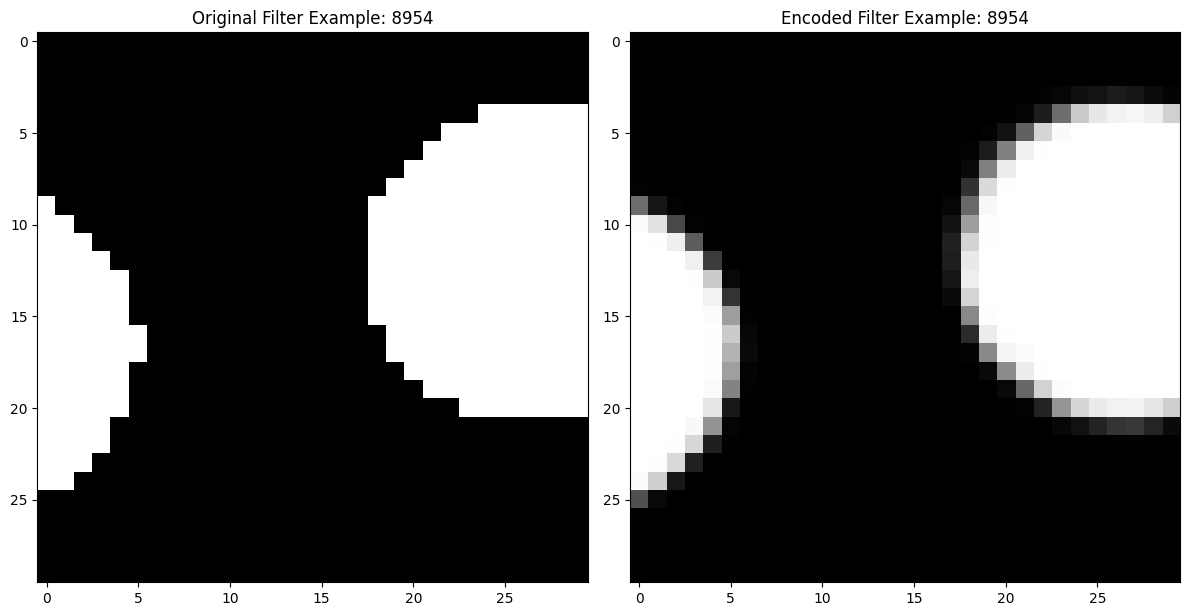

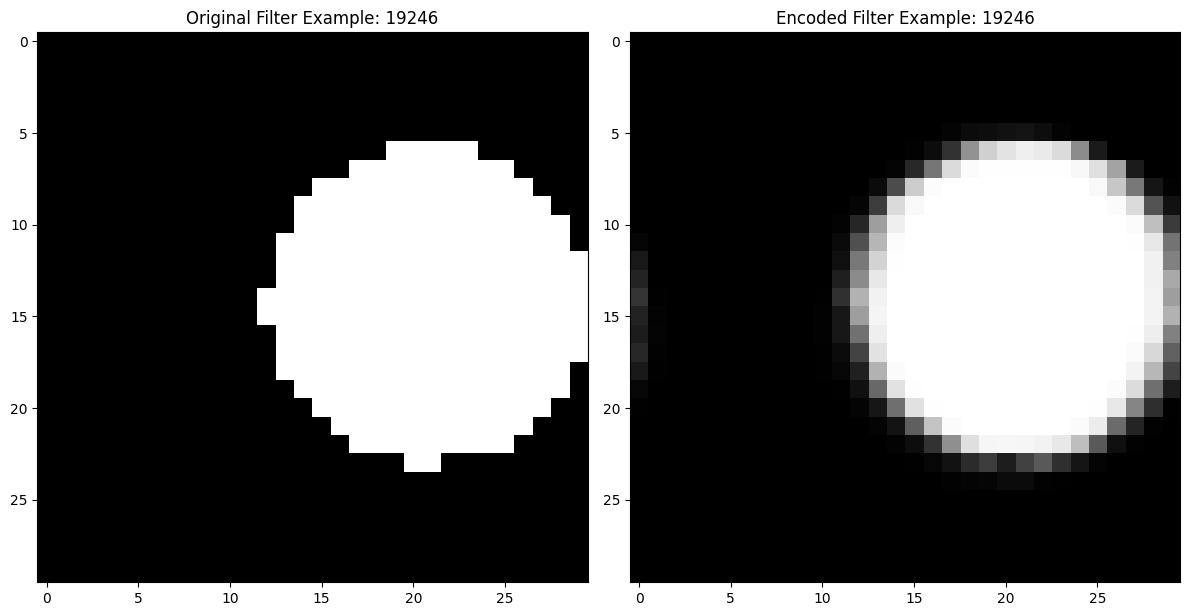

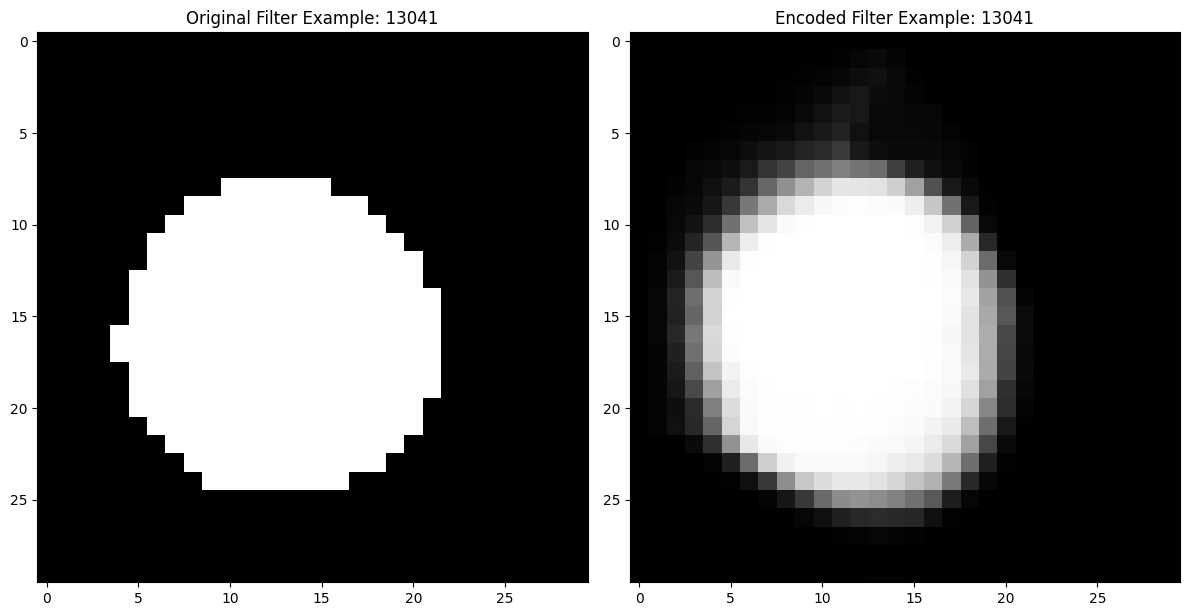

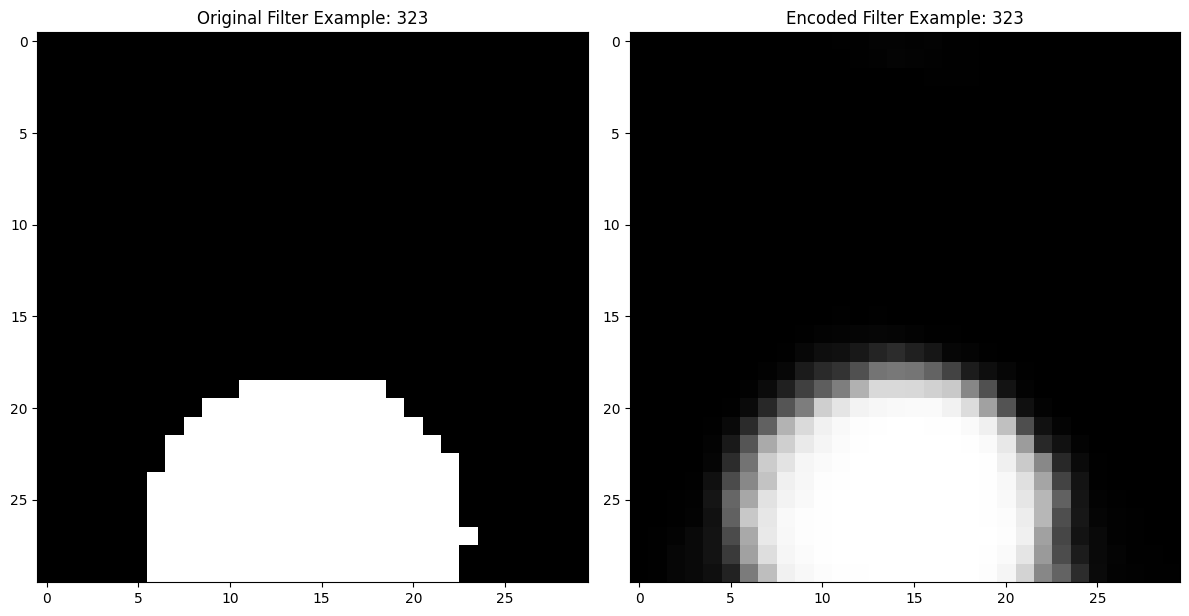

In [59]:
random_idx = np.random.randint(0, len(datamodule.val_dataloader().dataset), size=10) 

for i in random_idx:
    image = datamodule.val_dataloader().dataset[i][0]

    proj_rec = project_to_klein(klein_vae_module.encode(image)[0])
    print(proj_rec)
    rec = klein_vae_module.model.decode(proj_rec.reshape(1,-1)).reshape(IMG_SIZE, IMG_SIZE)

    #encoded_coords = klein_vae_module.encode(image.flatten())[0]
    #reconstructed_filter = klein_vae_module.decode(encoded_coords.reshape(1,-1)).reshape(40,40)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    #encoded_example = klein_vae_module.encode(filter_example.flatten())
    #encoded_filter = klein_vae_module.decode(encoded_example[0].unsqueeze(0))
    axes[1].imshow(rec.detach().cpu().numpy(), cmap='gray')
    axes[0].set_title(f'Original Filter Example: {i}')
    axes[1].set_title(f'Encoded Filter Example: {i}')
    plt.tight_layout()
    #plt.show()

In [30]:
#trainer.save_checkpoint('MODELS/HOORAY_CIRCLES.ckpt')

In [60]:
points_on_klein = torch.stack([klein_vae_module.encode(datamodule.val_dataloader().dataset[i][0])[0] 
                                for i in range(len(datamodule.val_dataloader().dataset))]).detach().numpy()

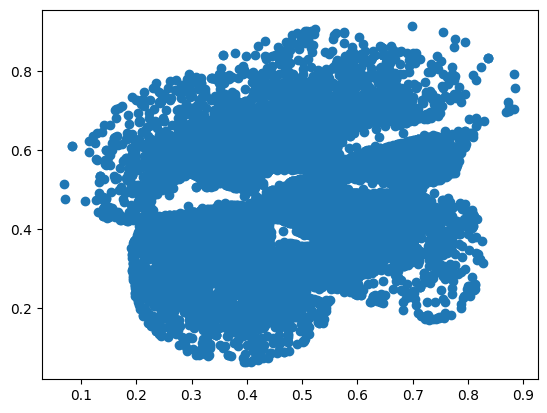

In [61]:
plt.scatter(points_on_klein[:,0], points_on_klein[:,1])

### Homology

In [134]:
dataset = datamodule.train_dataloader().dataset
indices = random.sample(range(len(dataset)), 500)
batch = np.array([dataset[i][0].numpy() for i in indices])

In [135]:
diagrams2 = ripser(batch, maxdim=2, coeff=2)['dgms']
diagrams3 = ripser(batch, maxdim=2, coeff=3)['dgms']

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_14330/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_14330/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


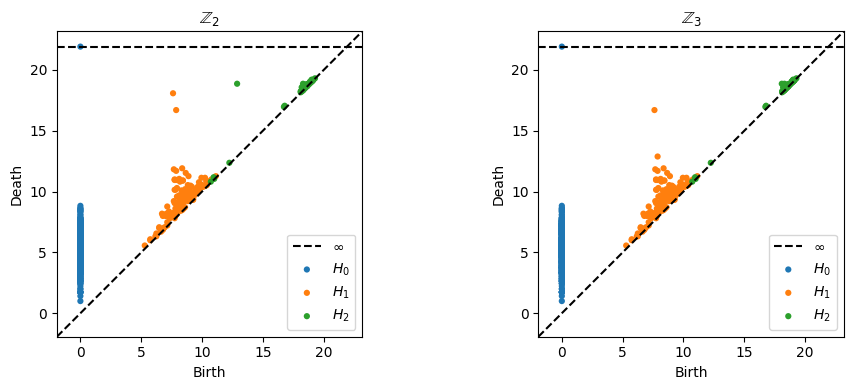

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

### Grid

In [62]:
#num_samples_per_angle = self.num_samples_per_angle
image_linear_pixel_size = IMG_SIZE
num_images = 20
circle_radius = 0.3

xs = torch.linspace(0,1,image_linear_pixel_size)
ys = torch.linspace(0,2,2*image_linear_pixel_size)

grid_x, grid_y = torch.meshgrid(xs, ys, indexing='ij')

imagess = []

imagess_flat = []

for i in range(num_images+1):
    images = []
    for j in range(num_images+1):
        # circle center
        cc_x = 1+(1.*i/(num_images-1))#1+2*torch.rand(1)
        cc_y = 2+1.*j/(num_images-1)#2+torch.rand(1)
        # 0,0
        gx, gy = grid_x, grid_y
        c00 = ((gx-cc_x)**2+(gy-cc_y)**2 < circle_radius**2)
        # 0,1
        gx, gy = grid_x, grid_y+2
        c01 = ((gx-cc_x)**2+(gy-cc_y)**2 < circle_radius**2)
        # 0,2
        gx, gy = grid_x, grid_y+4
        c02 = ((gx-cc_x)**2+(gy-cc_y)**2 < circle_radius**2)
        # 1,0
        gx, gy = grid_x+1, grid_y
        c10 = ((gx-cc_x)**2+(gy-cc_y)**2 < circle_radius**2)
        # 1,1
        gx, gy = grid_x+1, grid_y+2
        c11 = ((gx-cc_x)**2+(gy-cc_y)**2 < circle_radius**2)
        # 1,2
        gx, gy = grid_x+1, grid_y+4
        c12 = ((gx-cc_x)**2+(gy-cc_y)**2 < circle_radius**2)
        # 2,0
        gx, gy = grid_x+2, grid_y
        c20 = ((gx-cc_x)**2+(gy-cc_y)**2 < circle_radius**2)
        # 2,1
        gx, gy = grid_x+2, grid_y+2
        c21 = ((gx-cc_x)**2+(gy-cc_y)**2 < circle_radius**2)
        # 2,2
        gx, gy = grid_x+2, grid_y+4
        c22 = ((gx-cc_x)**2+(gy-cc_y)**2 < circle_radius**2)

        torus = (c00+c01+c02+c10+c11+c12+c20+c21+c22)

        klein = torus[:,:image_linear_pixel_size] + torch.flip(torus[:,image_linear_pixel_size:],dims=(0,))
        
        images.append(klein)
        
        imagess_flat.append(klein.flatten())
        
    imagess.append(images)
    
tensor = torch.stack(imagess_flat)

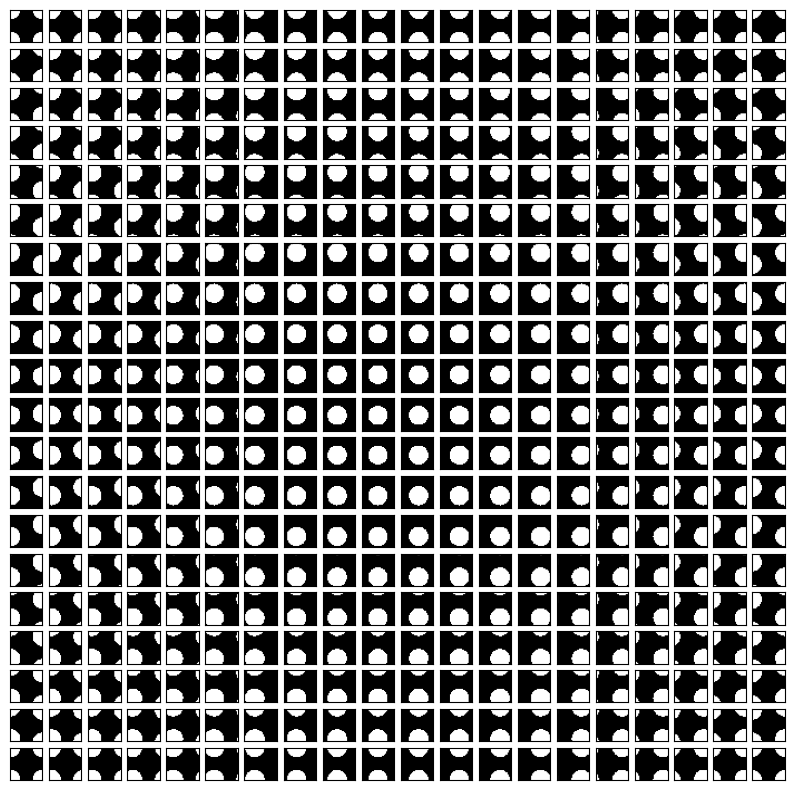

In [63]:
n = num_images

fig = plt.figure(figsize=(10,10))
ax = fig.subplots(n,n)

for i in range(0,n):
    for j in range(0,n):
        ax[i,j].imshow(imagess[i][j], 
                        cmap='gray')
        ax[i,j].axes.get_xaxis().set_ticks([])
        ax[i,j].axes.get_yaxis().set_ticks([])

### True Homology

In [71]:
batch = np.array([imagess[i][j].numpy().flatten() for i in range(len(imagess)) for j in range(len(imagess[i]))])
batch.shape

(441, 1600)

In [72]:
diagrams2 = ripser(batch, maxdim=2, coeff=2)['dgms']
diagrams3 = ripser(batch, maxdim=2, coeff=3)['dgms']

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_33402/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_33402/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


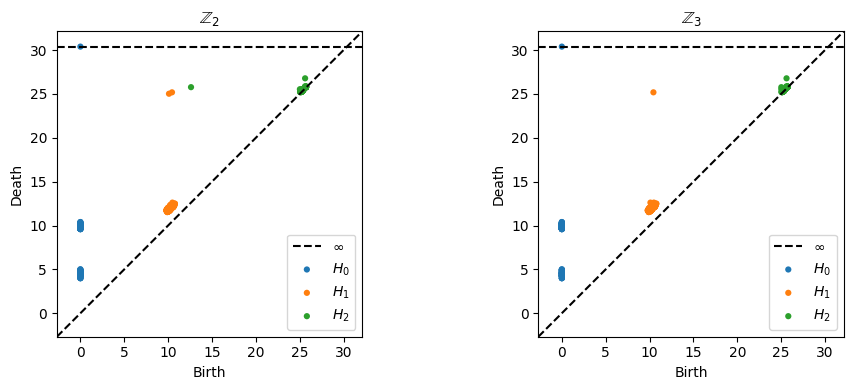

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

### Decoded grid values

In [64]:
encoded_values = klein_vae_module.encode(tensor.to(torch.float))[0]
decoded_images = klein_vae_module.decode(encoded_values)
decoded_images_square = decoded_images.reshape(num_images+1, num_images+1, image_linear_pixel_size, image_linear_pixel_size).detach().cpu().numpy()
decoded_images_np = decoded_images.detach().cpu().numpy()

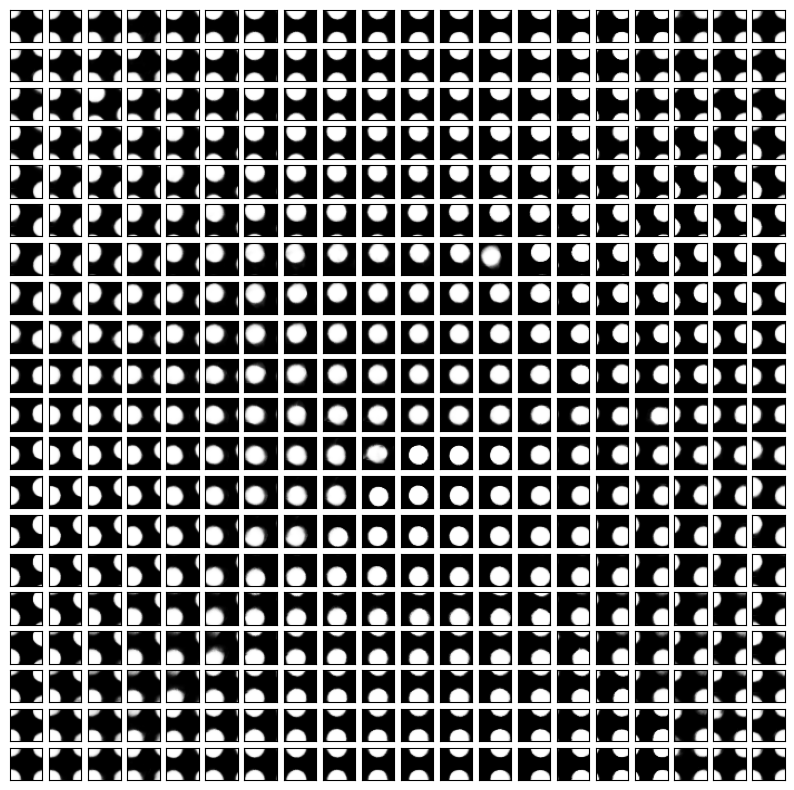

In [65]:
n = num_images

fig = plt.figure(figsize=(10,10))
ax = fig.subplots(n,n)

for i in range(0,n):
    for j in range(0,n):
        ax[i,j].imshow(decoded_images_square[i][j], 
                        cmap='gray')
        ax[i,j].axes.get_xaxis().set_ticks([])
        ax[i,j].axes.get_yaxis().set_ticks([])

In [66]:
diagrams2 = ripser(decoded_images_np, maxdim=2, coeff=2)['dgms']
diagrams3 = ripser(decoded_images_np, maxdim=2, coeff=3)['dgms']

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_38914/2732246747.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('Reconstructed Images over $\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_38914/2732246747.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('Reconstructed Images over $\mathbb{Z}_3$')


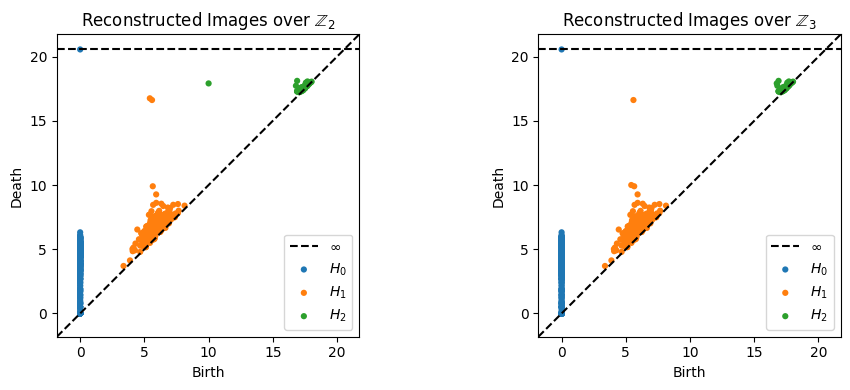

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Reconstructed Images over $\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Reconstructed Images over $\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()